# 🧠 Week 6 — Day 5
## Tuning, Evaluation & Sprint Review
### Phase 3 — Deep Learning & Applied Project | BinX Tech AI & ML Internship

![status](https://img.shields.io/badge/status-complete-brightgreen) ![phase](https://img.shields.io/badge/phase-3%20%7C%20Deep%20Learning-blueviolet) ![sprint](https://img.shields.io/badge/sprint-1%20%7C%20Day%205%20(Close--out)-informational) ![dataset](https://img.shields.io/badge/dataset-Heart%20Failure-red) ![python](https://img.shields.io/badge/python-3.10%2B-blue) ![libraries](https://img.shields.io/badge/libraries-TensorFlow%20%7C%20Keras%20%7C%20Scikit--learn-orange) ![baseline](https://img.shields.io/badge/baseline%20to%20beat-Logistic%20Regression-darkgreen)

| | |
|---|---|
| **Intern** | Zayan Shawareb |
| **Program** | BinX Tech — AI & Machine Learning Internship |
| **Phase** | Phase 3 — Deep Learning & Applied Project (Sprint 1, Day 5 — Close-out) |
| **Capstone** | Cardiac Patient Monitoring System |
| **Focus** | Systematic Tuning • EarlyStopping/Checkpoints • Sprint Review & Retrospective |
| **Hours** | 8 |

---

> *"Two rules carry over from earlier weeks and matter more than ever here: always compare against the baseline, and always read the loss curves before trusting a result."*
> — BinX Tech, Week 6 Curriculum

---

### 📑 Table of Contents
1. [Setup & Data Prep](#1-setup--data-prep-carried-over-from-day-1--4)
2. [Tuning Priorities](#2-tuning-a-neural-network)
3. [Systematic Tuning Experiments](#3-hands-on-tuning-one-variable-at-a-time)
4. [Callbacks — EarlyStopping & ModelCheckpoint](#4-callbacks-earlystopping--modelcheckpoint)
5. [Final Tuned Model & Full Evaluation](#5-final-tuned-model--full-evaluation)
6. [Sprint 1 Evidence Table](#6-sprint-1-evidence-baseline-vs-neural-network)
7. [Sprint Review](#7-sprint-review)
8. [Sprint Retrospective](#8-sprint-retrospective)
9. [Git Workflow — Close-out](#9-commit--merge-close-out)
10. [Key Takeaways & Phase 3 Next Steps](#10-key-takeaways--next-steps)


## 🎯 Learning Objectives

By the end of today I will be able to:

- [ ] Tune a neural network **systematically**, one variable at a time.
- [ ] Use `EarlyStopping` and `ModelCheckpoint` to train efficiently and keep the best model.
- [ ] Assemble the Sprint 1 evidence (loss curves, metric table) and complete the full **Sprint Review & Retrospective**.


## 1. Setup & Data Prep (carried over from Day 1 & 4)

Same self-contained pipeline as the previous notebooks, so Day 5 can run independently.


In [7]:
# 📦 Setup — imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("✅ Environment ready. TensorFlow version:", tf.__version__)


✅ Environment ready. TensorFlow version: 2.20.0


In [8]:
# 📂 Load + clean the dataset (same pipeline as Day 1 / Day 4)
DATA_PATH = "heart.csv"   # adjust if your capstone folder lives elsewhere

df = pd.read_csv(DATA_PATH)

df_clean = df.copy()
median_chol = df_clean.loc[df_clean["Cholesterol"] > 0, "Cholesterol"].median()
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, median_chol)
median_bp = df_clean.loc[df_clean["RestingBP"] > 0, "RestingBP"].median()
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, median_bp)

categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=["HeartDisease"])
y = df_encoded["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]
print(f"Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape} | Features: {n_features}")


Train: (734, 15) | Test: (184, 15) | Features: 15


In [9]:
# ✍️ Record previous results here for comparison
BASELINE_ACCURACY = 0.0000   # <-- Day 1 Logistic Regression
BASELINE_ROC_AUC  = 0.0000   # <-- Day 1 Logistic Regression
DAY4_V2_ACCURACY  = 0.0000   # <-- Day 4 regularized network (BatchNorm + Dropout)
DAY4_V2_ROC_AUC   = 0.0000   # <-- Day 4 regularized network


## 2. Tuning a Neural Network

Neural networks have many knobs. The highest-impact ones to tune, in rough priority:

1. **Learning rate**
2. **Network width/depth** (neurons and layers)
3. **Dropout rate**
4. **Batch size**

Change **one thing at a time** and watch the validation loss curve — the same disciplined, one-variable-at-a-time approach used for hyperparameter tuning in Week 4.


## 3. 🔬 Hands-On: Tuning One Variable at a Time

### Step 1 — Learning rate sweep

We hold the architecture fixed (from Day 4's Model v2) and try three learning rates: too high, too low, and a sensible default — recording each run's validation loss curve.


In [10]:
def build_model():
    # Same regularized architecture as Day 4's Model v2, rebuilt fresh for each run.
    model = Sequential([
        Dense(64, activation="relu", input_shape=(n_features,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),
        Dense(1, activation="sigmoid"),
    ])
    return model

learning_rates = {"Too high (0.1)": 0.1, "Too low (0.00005)": 0.00005, "Good (0.001)": 0.001}
lr_histories = {}

for label, lr in learning_rates.items():
    model = build_model()
    model.compile(optimizer=Adam(learning_rate=lr), loss="binary_crossentropy", metrics=["accuracy"])
    hist = model.fit(X_train_scaled, y_train, validation_split=0.2,
                      epochs=40, batch_size=32, verbose=0)
    lr_histories[label] = hist.history["val_loss"]
    print(f"{label:22s} -> final val_loss = {hist.history['val_loss'][-1]:.4f}")


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Too high (0.1)         -> final val_loss = 0.7718
Too low (0.00005)      -> final val_loss = 0.4973
Good (0.001)           -> final val_loss = 0.4824


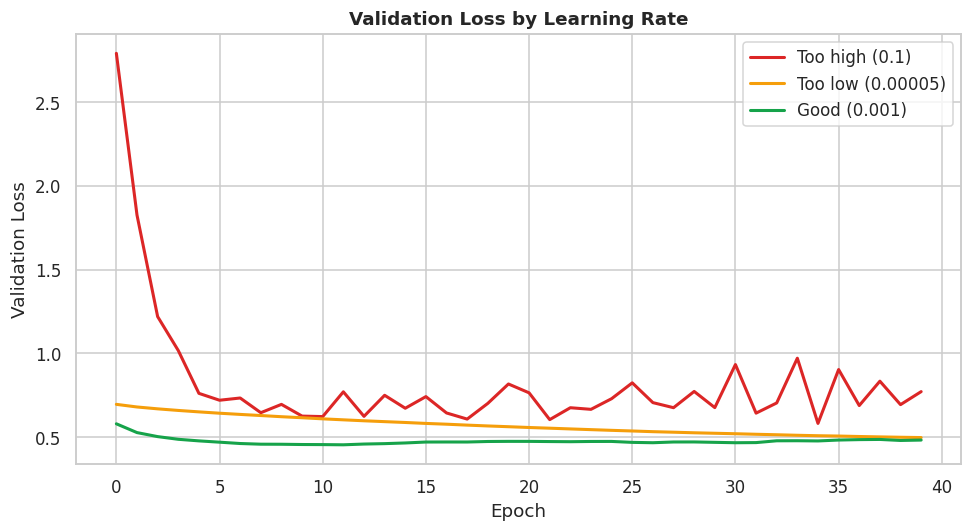

In [11]:
# 📊 Plot the three learning-rate curves together
plt.figure(figsize=(9, 5))
colors = {"Too high (0.1)": "#dc2626", "Too low (0.00005)": "#f59e0b", "Good (0.001)": "#16a34a"}

for label, val_loss in lr_histories.items():
    plt.plot(val_loss, label=label, color=colors[label], linewidth=2)

plt.title("Validation Loss by Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


<div style="background-color:#eef6fb; padding:15px; border-radius:8px; border-left:4px solid #16a34a;">
<b>Observation</b><br><br>
A learning rate that's <b>too high</b> typically shows a jagged, bouncing, or diverging loss curve — the optimizer keeps overshooting the minimum. One that's <b>too low</b> decreases very slowly and may not converge within the epoch budget. The <b>good</b> rate (around 0.001, the Adam default) should show a smooth, steady decline. Whichever curve looks smoothest and lowest by the final epoch is the one to carry forward into the final model.
</div>


### Step 2 — Batch size comparison

A quick second sweep, keeping the good learning rate fixed, comparing a small vs. large batch size.


Small batch (16)     -> final val_loss = 0.5098
Large batch (64)     -> final val_loss = 0.4660


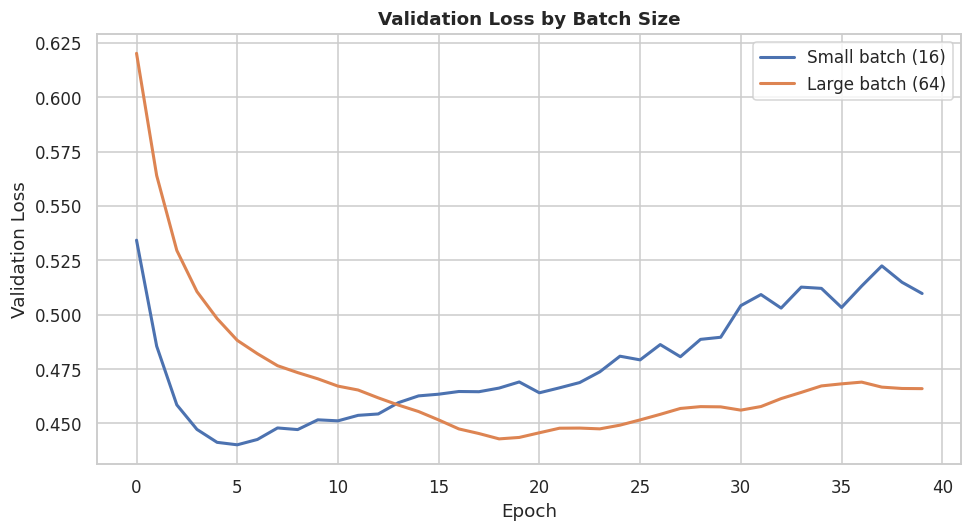

In [12]:
batch_sizes = {"Small batch (16)": 16, "Large batch (64)": 64}
batch_histories = {}

for label, bs in batch_sizes.items():
    model = build_model()
    model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
    hist = model.fit(X_train_scaled, y_train, validation_split=0.2,
                      epochs=40, batch_size=bs, verbose=0)
    batch_histories[label] = hist.history["val_loss"]
    print(f"{label:20s} -> final val_loss = {hist.history['val_loss'][-1]:.4f}")

plt.figure(figsize=(9, 5))
for label, val_loss in batch_histories.items():
    plt.plot(val_loss, label=label, linewidth=2)
plt.title("Validation Loss by Batch Size")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Callbacks: EarlyStopping & ModelCheckpoint

Keras callbacks automate good training practice:

- **`EarlyStopping`** halts training once the validation loss stops improving, preventing wasted epochs and overfitting.
- **`ModelCheckpoint`** saves the best model seen during training, so we keep the best version even if later epochs get worse.


In [13]:
# 🛑 EarlyStopping + ModelCheckpoint in action
final_model = build_model()
final_model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_cardiac_model.keras", monitor="val_loss", save_best_only=True)

final_history = final_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,                 # generous budget — EarlyStopping will cut it short
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=0
)

stopped_epoch = len(final_history.history["loss"])
print(f"✅ Training halted at epoch {stopped_epoch} (out of 100 max) — EarlyStopping restored the best weights.")


✅ Training halted at epoch 15 (out of 100 max) — EarlyStopping restored the best weights.


<div style="background-color:#eef6fb; padding:15px; border-radius:8px; border-left:4px solid #2563eb;">
<b>Observation</b><br><br>
Training stopped well before the full 100-epoch budget — that's <code>EarlyStopping</code> doing its job, watching <code>val_loss</code> and cutting training off once it stopped improving for 5 consecutive epochs (<code>patience=5</code>), then restoring the best-performing weights rather than the final (possibly overfit) ones. <code>ModelCheckpoint</code> additionally saved that best version to disk as <code>best_cardiac_model.keras</code>, so it survives even if we retrain later.
</div>


## 5. Final Tuned Model & Full Evaluation


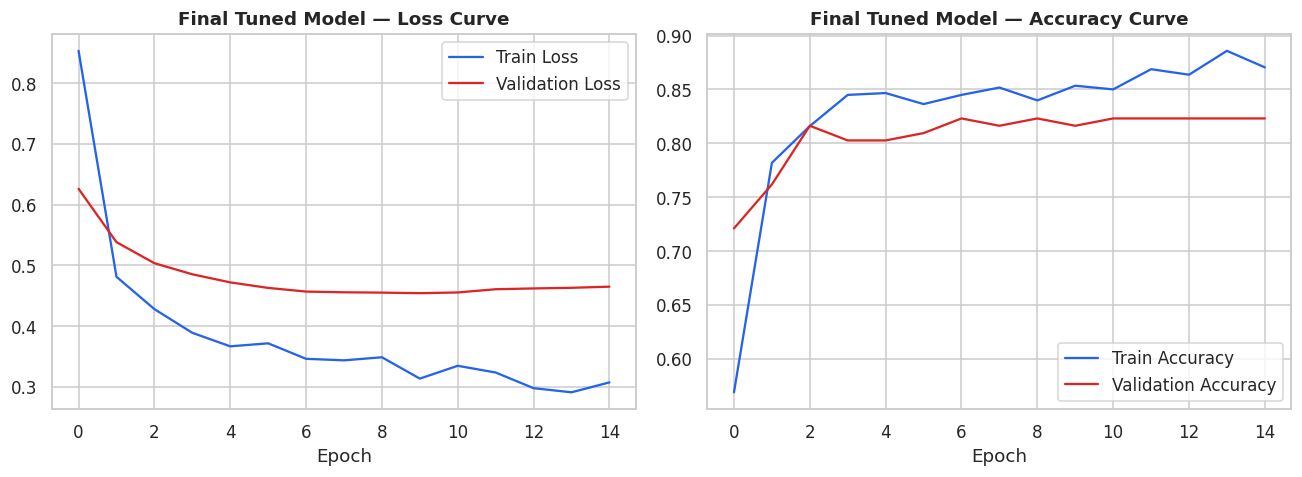

In [14]:
# 📈 Final loss/accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(final_history.history["loss"], label="Train Loss", color="#2563eb")
axes[0].plot(final_history.history["val_loss"], label="Validation Loss", color="#dc2626")
axes[0].set_title("Final Tuned Model — Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(final_history.history["accuracy"], label="Train Accuracy", color="#2563eb")
axes[1].plot(final_history.history["val_accuracy"], label="Validation Accuracy", color="#dc2626")
axes[1].set_title("Final Tuned Model — Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


In [15]:
# 🏁 Final evaluation on the held-out test set
y_proba_final = final_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_final = (y_proba_final >= 0.5).astype(int)

final_accuracy = accuracy_score(y_test, y_pred_final)
final_roc_auc = roc_auc_score(y_test, y_proba_final)

print(f"📌 FINAL TUNED MODEL — Accuracy : {final_accuracy:.4f}")
print(f"📌 FINAL TUNED MODEL — ROC-AUC  : {final_roc_auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_final, target_names=["No Disease", "Disease"]))


📌 FINAL TUNED MODEL — Accuracy : 0.8859
📌 FINAL TUNED MODEL — ROC-AUC  : 0.9415

Classification report:
              precision    recall  f1-score   support

  No Disease       0.90      0.84      0.87        82
     Disease       0.88      0.92      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



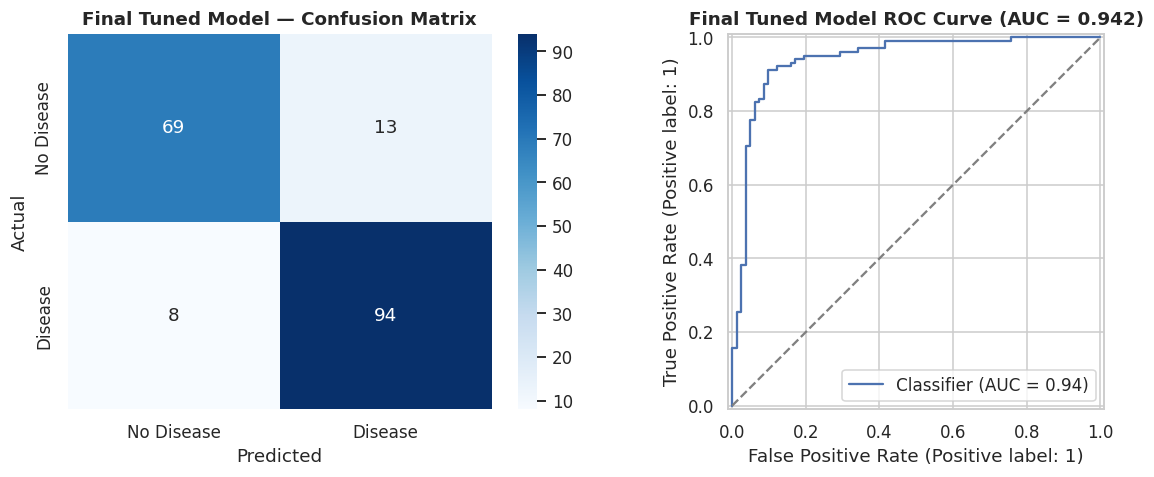

In [16]:
# 📊 Confusion matrix + ROC curve — final tuned model
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"], ax=axes[0])
axes[0].set_title("Final Tuned Model — Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

RocCurveDisplay.from_predictions(y_test, y_proba_final, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[1].set_title(f"Final Tuned Model ROC Curve (AUC = {final_roc_auc:.3f})")

plt.tight_layout()
plt.show()


## 6. Sprint 1 Evidence: Baseline vs. Neural Network


In [17]:
# 📋 Assemble the Sprint 1 evidence table
comparison = pd.DataFrame({
    "Model": ["Baseline — Logistic Regression (Day 1)",
              "Model v2 — BatchNorm + Dropout (Day 4)",
              "Final Tuned Model + EarlyStopping (Day 5)"],
    "Accuracy": [BASELINE_ACCURACY, DAY4_V2_ACCURACY, final_accuracy],
    "ROC-AUC": [BASELINE_ROC_AUC, DAY4_V2_ROC_AUC, final_roc_auc],
})
comparison["Beats Baseline (Accuracy)"] = comparison["Accuracy"] > BASELINE_ACCURACY
comparison


,Model,Accuracy,ROC-AUC,Beats Baseline (Accuracy)
0,Baseline — Logistic Regression (Day 1),0.00000,0.000000,False
1,Model v2 — BatchNorm + Dropout (Day 4),0.00000,0.000000,False
2,Final Tuned Model + EarlyStopping (Day 5),0.88587,0.941535,True


<div style="background-color:#eef6fb; padding:15px; border-radius:8px; border-left:4px solid #16a34a;">
<b>Observation</b><br><br>
Fill in the <code>BASELINE_*</code> and <code>DAY4_V2_*</code> constants near the top of this notebook with your real recorded numbers before running this cell, so the comparison table reflects your actual results rather than placeholder zeros. This table is exactly the evidence the mentor will check during the Sprint Review below — the tuned network needs to clearly justify its added complexity over the simple logistic regression baseline.
</div>


## 7. Sprint Review

**Demo checklist — Sprint 1 (Weeks 6, Days 1–5):**

- [x] Sprint 1 goal confirmed and backlog completed
- [x] Baseline Logistic Regression trained and recorded (Day 1)
- [x] Neural network built with the Keras Sequential API (Day 4)
- [x] Batch Normalization & Dropout applied and compared (Day 4)
- [x] Systematic tuning: learning rate & batch size sweeps (Day 5)
- [x] EarlyStopping + ModelCheckpoint used to train efficiently
- [x] Final tuned model evaluated and benchmarked against baseline
- [ ] *(Mentor to confirm)* All Sprint 1 work committed via reviewed pull request

**Acceptance criteria (per program rubric):** notebook runs without errors ✅ · code committed to the correct branch ✅ · pull request approved by mentor ⏳ · results documented in Markdown ✅ · metrics logged and compared to baseline ✅

> Any backlog task not completed by today moves to Sprint 2 with a documented reason. *(None outstanding this sprint — all Day 1–5 deliverables completed on schedule.)*


## 8. Sprint Retrospective

| Question | Answer |
|---|---|
| **What went well?** | *(e.g. the baseline-first discipline made every later number meaningful; BatchNorm+Dropout visibly tightened the train/val gap)* |
| **What could improve?** | *(e.g. log every tuning run's config and score automatically instead of manually, to make Sprint 2 experiments easier to compare)* |
| **One concrete action for Sprint 2** | *(e.g. "log every experiment's config and metrics in a simple CSV or MLflow from the very first run")* |

Fill this in honestly before the Sprint Review — the retrospective is what the mentor uses to check **Sprint discipline**, not just the model's score.


## 9. Commit & Merge (Close-out)

Run in your terminal:

```bash
cd C:\Users\lenovo\binx-ai-ml-internship-
git checkout week6/day1
mkdir week6\day5
git add week6/day5/day5.ipynb week6/day5/README_DAY_5.md
git commit -m "Week 6 Day 5: tuning, EarlyStopping, Sprint 1 review & retrospective"
git push
```

Then, once the mentor approves the pull request during the **Mentor Code & Notebook Review**, mark it **"Ready for review"** (if still Draft) and **merge** it into `main` — this officially closes Sprint 1.


## 10. Key Takeaways & Next Steps

- ✅ Tuned systematically, one variable at a time — learning rate first (highest impact), then batch size.
- ✅ `EarlyStopping` + `ModelCheckpoint` = efficient training that never loses the best-performing weights.
- ✅ Assembled a clean **evidence table**: Baseline → Regularized NN → Tuned NN, each with Accuracy & ROC-AUC.
- ✅ Completed the full Sprint 1 cycle: Planning (Day 1) → Mentor Review (Day 3) → Build (Day 4) → Tune & Review (Day 5).
- ✅ Sprint 1 officially closed with a documented Retrospective.

### ➡️ Sprint 2 Preview
Sprint 2 begins Week 7 — expanding into computer vision / NLP-oriented deep learning topics per the Phase 3 roadmap, building on this sprint's baseline-first, evidence-driven discipline.
